In [40]:
pip install opencv-contrib-python scikit-image pywavelets matplotlib pandas scikit-learn

In [41]:
!pip install keras-facenet

In [42]:
import cv2
import os
import numpy as np
import pywt
import pandas as pd
import matplotlib.pyplot as plt
from keras_facenet import FaceNet
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
!ls "/content/drive/MyDrive/DIP Dataset 2 Faces 94/faces94"

9326871  ajones   cjcarr  drbost  irdrew  lejnno   nahaig  pspliu  sidick
9332898  ajsega   cjdenn  ekavaz  jabins  lfso	   namull  ptnich  sjbeck
9336923  akatsi   cjsake  elduns  jagrif  lyond    ndbank  rarobi  skumar
9338446  ambarw   cmkirk  fordj   jcarte  maasht   ndhagu  rgharr  slbirc
9338454  anonym   csanch  gdhatc  jdbenm  macci    nhrams  rgspru  smrobb
9338462  anonym1  cshubb  ggeorg  jgloma  martin   njmoor  rjlabr  spacl
9338489  anonym2  cwang   ggrego  jlemon  mberdo   npbour  rlocke  spletc
9338497  anpage   cwchoi  gjhero  jmedin  mbutle   npmitc  rmcoll  svkriz
9338519  asamma   dagran  gjnorm  jrtobi  mdpove   nrclar  rmpugh  swewin
9338527  asewil   dakram  gmwate  kaatki  mefait   nrrbar  rnpwil  swsmit
9338535  asheal   dcbowe  gotone  kaknig  mhwill   nwilli  robin   tony
9338543  astefa   dioann  gpapaz  kdjone  miaduc   obeidn  rrowle  voudcx
9414649  bplyce   djbirc  gpsmit  khchan  michael  ohpark  rsanti  vpsavo
9416994  cchris   djhugh  gsreas  khughe  

In [45]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/DIP Dataset 2 Faces 94/faces94"

images = []
labels = []

label_id = 0

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gray = cv2.resize(gray, (100,100))

        images.append(gray)
        labels.append(label_id)

    label_id += 1

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 3059
Total labels: 3059


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.5,
    stratify=labels,
    random_state=42
)

In [47]:
def compute_metrics(preds):

    acc = accuracy_score(y_test,preds)*100
    prec = precision_score(y_test,preds,average='macro')*100
    rec = recall_score(y_test,preds,average='macro')*100
    f1 = f1_score(y_test,preds,average='macro')*100

    return acc,prec,rec,f1

In [48]:
def image_quality(original, processed):

    original = original.astype(np.uint8)
    processed = processed.astype(np.uint8)

    p = psnr(original, processed, data_range=255)

    s, _ = ssim(original, processed, full=True, data_range=255)

    return p, s

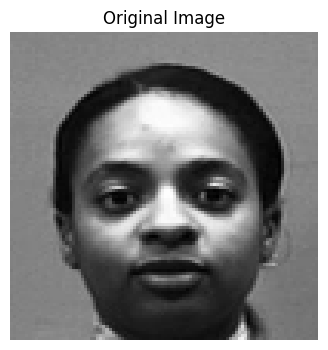

In [49]:
import matplotlib.pyplot as plt

sample = images[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [50]:
def median_filter(img):
    return cv2.medianBlur(img,3)

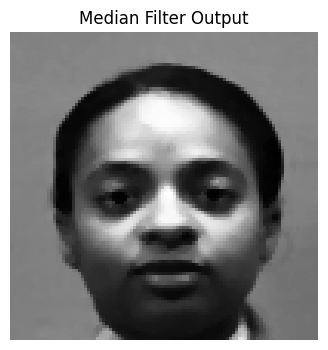

In [51]:
median_img = median_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(median_img, cmap='gray')
plt.title("Median Filter Output")
plt.axis("off")
plt.show()

In [52]:
def gray_normalization(img):

    norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)

    return norm

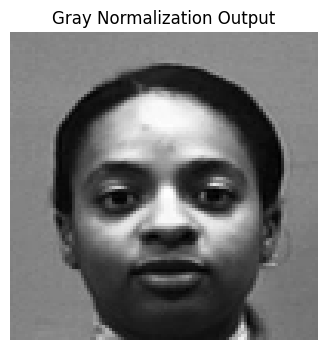

In [53]:
graynorm_img = gray_normalization(sample)

plt.figure(figsize=(4,4))
plt.imshow(graynorm_img, cmap='gray')
plt.title("Gray Normalization Output")
plt.axis("off")
plt.show()

In [54]:
def geometric_norm(img):

    rows,cols = img.shape

    M = cv2.getRotationMatrix2D((cols/2,rows/2),5,1)

    return cv2.warpAffine(img,M,(cols,rows))

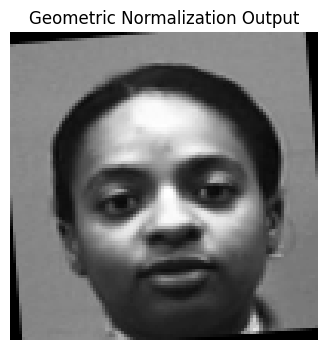

In [55]:
geom_img = geometric_norm(sample)

plt.figure(figsize=(4,4))
plt.imshow(geom_img, cmap='gray')
plt.title("Geometric Normalization Output")
plt.axis("off")
plt.show()

In [56]:
def wavelet_transform(img):

    coeffs = pywt.dwt2(img,'haar')

    LL,(LH,HL,HH) = coeffs

    return cv2.resize(LL,(100,100))

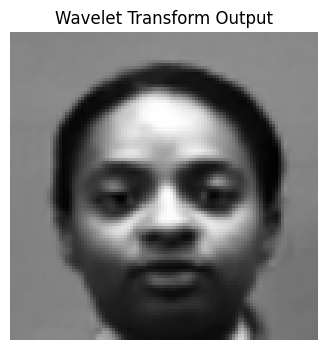

In [57]:
wavelet_img = wavelet_transform(sample)

plt.figure(figsize=(4,4))
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Transform Output")
plt.axis("off")
plt.show()

In [58]:
def hist_eq(img):

    return cv2.equalizeHist(img)

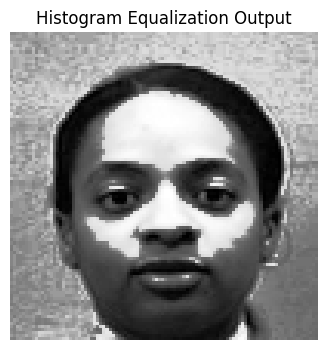

In [59]:
hist_img = hist_eq(sample)

plt.figure(figsize=(4,4))
plt.imshow(hist_img, cmap='gray')
plt.title("Histogram Equalization Output")
plt.axis("off")
plt.show()

In [60]:
methods = {
"Original":lambda x:x,
"Median":median_filter,
"GrayNorm":gray_normalization,
"Geometric":geometric_norm,
"Wavelet":wavelet_transform,
"Histogram":hist_eq,
}

results=[]
accuracies=[]

In [61]:
from keras_facenet import FaceNet
from sklearn.svm import SVC

embedder = FaceNet()

In [62]:
def prepare_for_facenet(images):

    processed = []

    for img in images:

        img = img.astype(np.uint8)

        img = cv2.resize(img,(160,160))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        processed.append(img)

    return np.array(processed)

In [63]:
results=[]

for name, func in methods.items():

    # Apply preprocessing
    X_train_proc = np.array([func(img) for img in X_train])
    X_test_proc = np.array([func(img) for img in X_test])

    # Convert for FaceNet
    X_train_face = prepare_for_facenet(X_train_proc)
    X_test_face = prepare_for_facenet(X_test_proc)

    # Face embeddings
    train_embeddings = embedder.embeddings(X_train_face)
    test_embeddings = embedder.embeddings(X_test_face)

    # Train classifier
    model = SVC(kernel='linear', C=0.5)
    model.fit(train_embeddings, y_train)

    preds = model.predict(test_embeddings)

    # Classification metrics
    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds, average='macro') * 100
    rec = recall_score(y_test, preds, average='macro') * 100
    f1 = f1_score(y_test, preds, average='macro') * 100

    # Image quality metrics
    psnr_vals = []
    ssim_vals = []

    for i in range(len(X_test)):
        p, s = image_quality(X_test[i], X_test_proc[i])
        psnr_vals.append(p)
        ssim_vals.append(s)

    psnr_avg = np.mean(psnr_vals)
    ssim_avg = np.mean(ssim_vals)

    results.append([name, acc, prec, rec, f1, psnr_avg, ssim_avg])

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("PSNR:", psnr_avg)
    print("SSIM:", ssim_avg)
    print("---------------------")

48/48 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Original
Accuracy: 99.34640522875817
Precision: 98.75222816399287
Recall: 99.34640522875817
F1 Score: 99.03516962340491
PSNR: inf
SSIM: 1.0
---------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Median
Accuracy: 99.34640522875817
Precision: 98.75222816399287
Recall: 99.34640522875817
F1 Score: 99.03516962340491
PSNR: 33.983593158846645
SSIM: 0.962744693798527
---------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step


...

Geometric
Accuracy: 99.34640522875817
Precision: 98.75222816399287
Recall: 99.34640522875817
F1 Score: 99.03516962340491
PSNR: 18.47552578056498
SSIM: 0.6554648511736096
---------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Wavelet
Accuracy: 97.45098039215686
Precision: 97.15488215488216
Recall: 97.45098039215686
F1 Score: 97.13839825993045
PSNR: 9.914601714402744
SSIM: 0.4388573131829268
---------------------
48/48 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Histogram
Accuracy: 99.34640522875817
Precision: 98.75222816399287
Recall: 99.34640522875817
F1 Score: 99.03516962340491
PSNR: 15.153003424835509
SSIM: 0.7230482678386063
---------------------


In [64]:
columns = ["Method","Accuracy","Precision","Recall","F1 Score","PSNR","SSIM"]

df = pd.DataFrame(results, columns=columns)

print(df)

      Method   Accuracy  Precision     Recall   F1 Score       PSNR      SSIM
0   Original  99.346405  98.752228  99.346405  99.035170        inf  1.000000
1     Median  99.346405  98.752228  99.346405  99.035170  33.983593  0.962745
2   GrayNorm  99.346405  98.752228  99.346405  99.035170  34.543151  0.993086
3  Geometric  99.346405  98.752228  99.346405  99.035170  18.475526  0.655465
4    Wavelet  97.450980  97.154882  97.450980  97.138398   9.914602  0.438857
5  Histogram  99.346405  98.752228  99.346405  99.035170  15.153003  0.723048


In [65]:
display(df)

,Method,Accuracy,Precision,Recall,F1 Score,PSNR,SSIM
0,Original,99.346405,98.752228,99.346405,99.035170,inf,1.000000
1,Median,99.346405,98.752228,99.346405,99.035170,33.983593,0.962745
2,GrayNorm,99.346405,98.752228,99.346405,99.035170,34.543151,0.993086
3,Geometric,99.346405,98.752228,99.346405,99.035170,18.475526,0.655465
4,Wavelet,97.450980,97.154882,97.450980,97.138398,9.914602,0.438857
5,Histogram,99.346405,98.752228,99.346405,99.035170,15.153003,0.723048


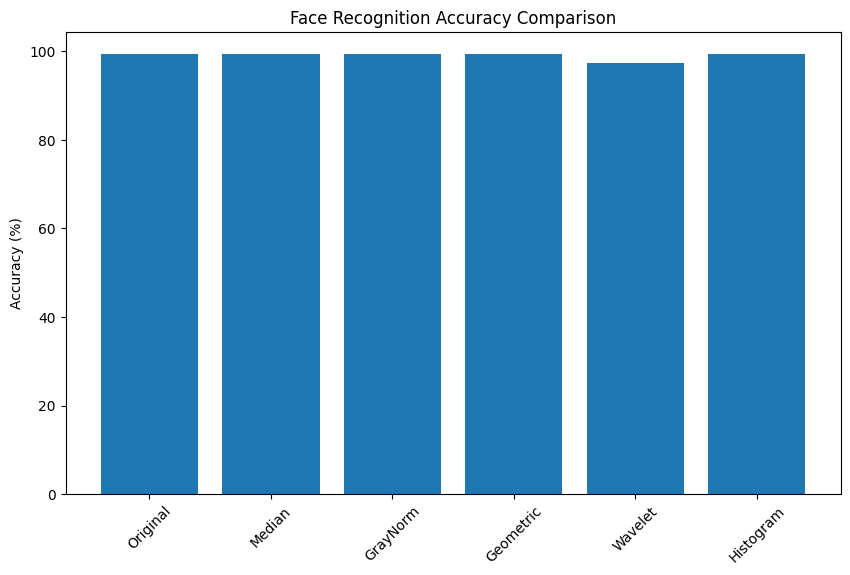

In [66]:
methods_list = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(10,6))
plt.bar(methods_list, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Face Recognition Accuracy Comparison")
plt.show()

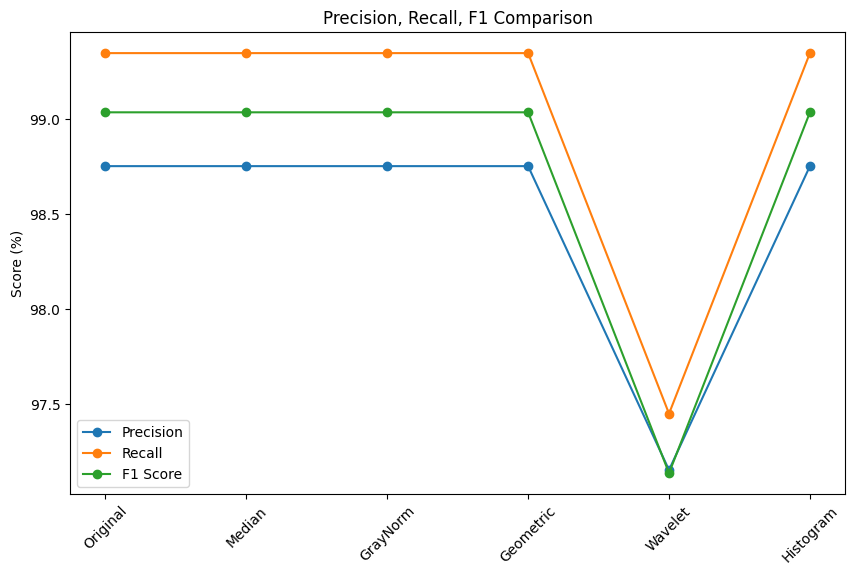

In [67]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Method"], df["Recall"], marker='o', label="Recall")
plt.plot(df["Method"], df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=45)

plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1 Comparison")

plt.legend()

plt.show()

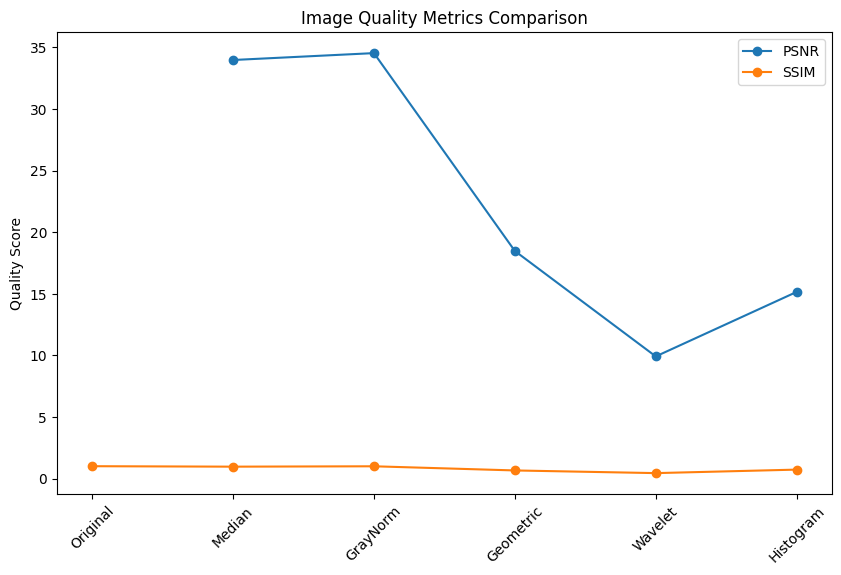

In [68]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["PSNR"], marker='o', label="PSNR")
plt.plot(df["Method"], df["SSIM"], marker='o', label="SSIM")

plt.xticks(rotation=45)

plt.ylabel("Quality Score")
plt.title("Image Quality Metrics Comparison")

plt.legend()

plt.show()

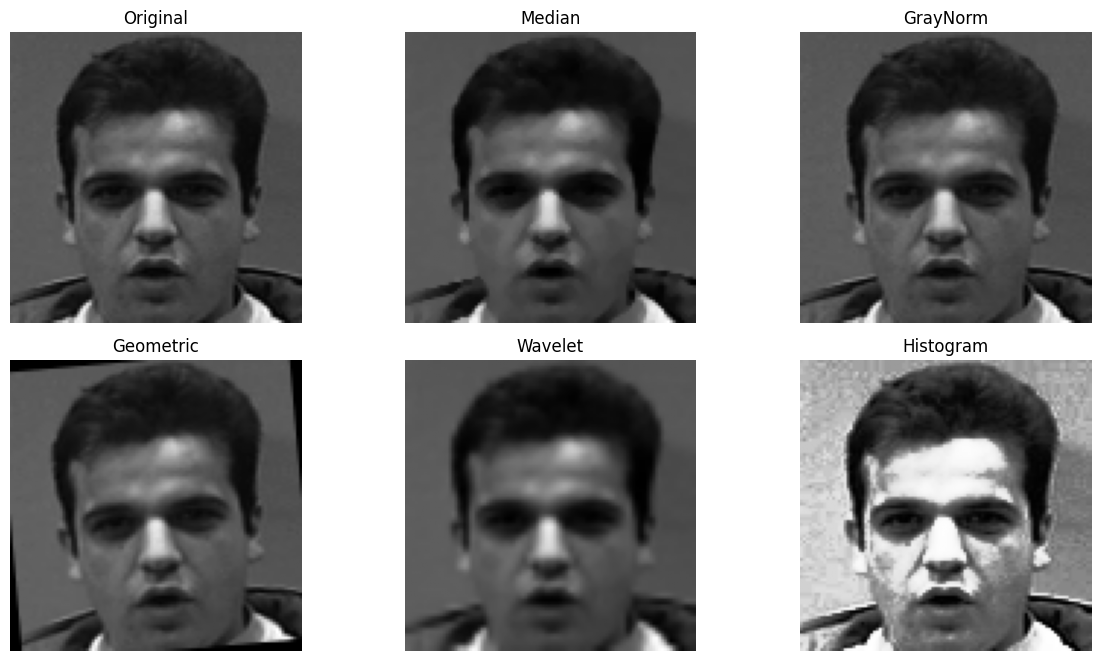

In [69]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(12,10))

# show original
plt.subplot(3,3,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

i = 2

for name, func in methods.items():

    if name == "Original":
        continue

    processed = func(sample)

    plt.subplot(3,3,i)
    plt.imshow(processed, cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()